In [16]:
from scipy.fft import fft2
import xarray as xr
import numpy as np
from scipy.spatial import cKDTree
import json
import yaml
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

In [2]:
def combine_state_features(ds):
    """
    Combine individual state features from an xarray.Dataset into a single dataset.

    Parameters:
    ds (xarray.Dataset): The input dataset containing state features.

    Returns:
    xarray.Dataset: A new dataset with each state feature as a separate variable.
    """
    # Create a new dataset to hold the combined features
    combined_ds = xr.Dataset()

    # Loop through each state feature and add it to the combined dataset
    for feature in ds.state_feature.values:
        individual_array = ds.state.sel(state_feature=feature)
        combined_ds[feature] = individual_array

    return combined_ds

In [3]:
ds_interior = xr.open_zarr("../data/datastore.interior.zarr")
creation_config_yaml = yaml.safe_load(ds_interior.attrs["creation_config"])
del ds_interior.attrs["creation_config"]
lats = np.rad2deg(ds_interior["clat"])
lons = np.rad2deg(ds_interior["clon"])
ds_interior = combine_state_features(ds_interior)

path_mllam = "../example-peppy-rubs.zarr"
ds_mllam = xr.open_zarr(path_mllam, consolidated=False)
ds_mllam = combine_state_features(ds_mllam)

/tmp/ipykernel_359594/487923242.py:9: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_mllam = xr.open_zarr(path_mllam, consolidated=False)


In [4]:
ds_mllam

<xarray.Dataset> Size: 113GB
Dimensions:                    (elapsed_forecast_duration: 10,
                                grid_index: 524288, start_time: 895)
Coordinates:
  * elapsed_forecast_duration  (elapsed_forecast_duration) timedelta64[ns] 80B ...
  * grid_index                 (grid_index) int64 4MB 5618205 ... 7148143
  * start_time                 (start_time) datetime64[ns] 7kB 2020-02-12T00:...
    state_feature              <U8 32B 't_2m'
    time                       (elapsed_forecast_duration) datetime64[ns] 80B dask.array<chunksize=(1,), meta=np.ndarray>
Data variables:
    t_2m                       (start_time, elapsed_forecast_duration, grid_index) float32 19GB dask.array<chunksize=(1, 1, 524288), meta=np.ndarray>
    u_10m                      (start_time, elapsed_forecast_duration, grid_index) float32 19GB dask.array<chunksize=(1, 1, 524288), meta=np.ndarray>
    v_10m                      (start_time, elapsed_forecast_duration, grid_index) float32 19GB dask.array<chunksize=(1, 1, 524288), meta=np.ndarray>
    pres_sfc                   (start_time, elapsed_forecast_duration, grid_index) float32 19GB dask.array<chunksize=(1, 1, 524288), meta=np.ndarray>
    qv_2m                      (start_time, elapsed_forecast_duration, grid_index) float32 19GB dask.array<chunksize=(1, 1, 524288), meta=np.ndarray>
    tqc_dia                    (start_time, elapsed_forecast_duration, grid_index) float32 19GB dask.array<chunksize=(1, 1, 524288), meta=np.ndarray>

In [5]:
ds_interior

<xarray.Dataset> Size: 70GB
Dimensions:                       (grid_index: 524288, time: 5543)
Coordinates:
    clat                          (grid_index) float64 4MB dask.array<chunksize=(524288,), meta=np.ndarray>
    clon                          (grid_index) float64 4MB dask.array<chunksize=(524288,), meta=np.ndarray>
  * grid_index                    (grid_index) int64 4MB 5618205 ... 7148143
    state_feature                 <U8 32B 't_2m'
    state_feature_long_name       <U48 192B dask.array<chunksize=(), meta=np.ndarray>
    state_feature_source_dataset  <U11 44B dask.array<chunksize=(), meta=np.ndarray>
    state_feature_units           <U8 32B dask.array<chunksize=(), meta=np.ndarray>
  * time                          (time) datetime64[ns] 44kB 2020-01-11T22:20...
Data variables:
    t_2m                          (time, grid_index) float32 12GB dask.array<chunksize=(1, 524288), meta=np.ndarray>
    u_10m                         (time, grid_index) float32 12GB dask.array<chunksize=(1, 524288), meta=np.ndarray>
    v_10m                         (time, grid_index) float32 12GB dask.array<chunksize=(1, 524288), meta=np.ndarray>
    pres_sfc                      (time, grid_index) float32 12GB dask.array<chunksize=(1, 524288), meta=np.ndarray>
    qv_2m                         (time, grid_index) float32 12GB dask.array<chunksize=(1, 524288), meta=np.ndarray>
    tqc_dia                       (time, grid_index) float32 12GB dask.array<chunksize=(1, 524288), meta=np.ndarray>

In [6]:
import copy

def projection(projection_info):
    """Create a cartopy projection from a projection info dictionary.
    """
    class_name = projection_info["class_name"]
    ProjectionClass = getattr(ccrs, class_name)
    # need to copy otherwise we modify the dict stored in the dataclass
    # in-place
    kwargs = copy.deepcopy(projection_info["kwargs"])

    globe_kwargs = kwargs.pop("globe", {})
    if len(globe_kwargs) > 0:
        kwargs["globe"] = ccrs.Globe(**globe_kwargs)
    
    return ProjectionClass(**kwargs)

In [7]:
model_proj = projection(creation_config_yaml["extra"]["projection"])

# Extract unstructured grid coordinates
# Adjust these variable names if needed
grid_lat = np.rad2deg(ds_interior['clat'].isel(grid_index=slice(0,-1)).values)
grid_lon = np.rad2deg(ds_interior['clon'].isel(grid_index=slice(0,-1)).values)

xyz = model_proj.transform_points(
        ccrs.PlateCarree(), grid_lon, grid_lat
    )

# projected X, Y
# Stack coordinates for KDTree
grid_points = np.column_stack((xyz[:,0], xyz[:,1]))
center_pos = grid_points.mean(axis=0)

x = np.arange(center_pos[0]-60000, center_pos[0]+60000, 400)
y = np.arange(center_pos[1]-98000, center_pos[1]+98000, 400)
target_x, target_y = np.meshgrid(x, y)
target_points = np.column_stack((target_x.flatten(), target_y.flatten()))
# Build KDTree and query nearest neighbors
max_dist = 400  # example: meters, adjust as needed
tree = cKDTree(grid_points)
distances, idx = tree.query(target_points)

/home/has/repos/mllam-exps-ShCu/.venv/lib/python3.12/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


In [8]:
gt_regridded_data = {}
variables = ['t_2m', 'qv_2m', 'u_10m', 'v_10m', 'tqc_dia', 'pres_sfc']
for var in variables:
    data = ds_interior[var].isel(grid_index=idx).values.reshape(len(ds_interior.time), len(y), len(x))
    # Map data from unstructured grid to regular grid
    # regridded[distances.reshape(len(y), len(x), -1) > max_dist] = np.nan  # Mask out points beyond max_dist
    gt_regridded_data[var] = (["time", "y", "x"], data)

gt_regridded = xr.Dataset(
    gt_regridded_data,
    coords={"y": y, "x": x, "time": ds_interior.time.values}
)

mllam_regridded_data = {}
for var in variables:
    data = ds_mllam[var].isel(grid_index=idx).values.reshape(len(ds_mllam.start_time), len(ds_mllam.elapsed_forecast_duration), len(y), len(x))
    # Map data from unstructured grid to regular grid
    # regridded[distances.reshape(len(y), len(x), -1) > max_dist] = np.nan  # Mask out points beyond max_dist
    mllam_regridded_data[var] = (["start_time", "elapsed_forecast_duration", "y", "x"], data)
mllam_regridded = xr.Dataset(
    mllam_regridded_data,
    coords={"y": y, "x": x, "start": ds_mllam.start_time.values, "elapsed_forecast_duration": ds_mllam.elapsed_forecast_duration.values}
)


In [9]:
gt_regridded

<xarray.Dataset> Size: 20GB
Dimensions:   (time: 5543, y: 490, x: 300)
Coordinates:
  * y         (y) float64 4kB -9.789e+04 -9.749e+04 ... 9.731e+04 9.771e+04
  * x         (x) float64 2kB -6.01e+04 -5.97e+04 ... 5.91e+04 5.95e+04
  * time      (time) datetime64[ns] 44kB 2020-01-11T22:20:00 ... 2020-02-19T1...
Data variables:
    t_2m      (time, y, x) float32 3GB 299.4 299.4 299.4 ... 297.9 298.0 298.0
    qv_2m     (time, y, x) float32 3GB 0.01557 0.01556 ... 0.01544 0.01545
    u_10m     (time, y, x) float32 3GB -9.142 -9.81 -10.1 ... -8.732 -8.614
    v_10m     (time, y, x) float32 3GB -2.095 -1.908 -1.858 ... 0.774 0.7702
    tqc_dia   (time, y, x) float32 3GB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    pres_sfc  (time, y, x) float32 3GB 1.016e+05 1.016e+05 ... 1.017e+05

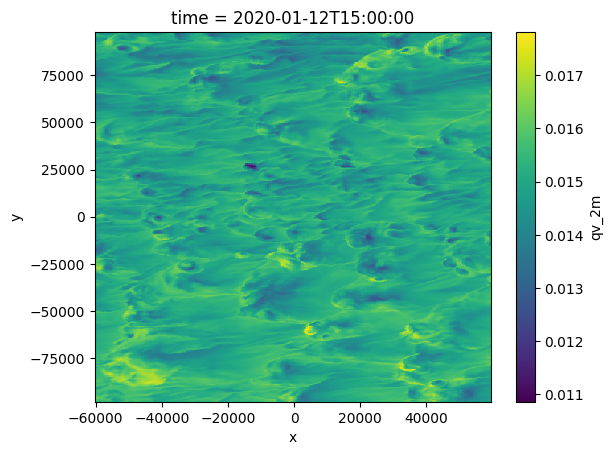

In [10]:
gt_regridded.qv_2m.isel(time=100).plot()

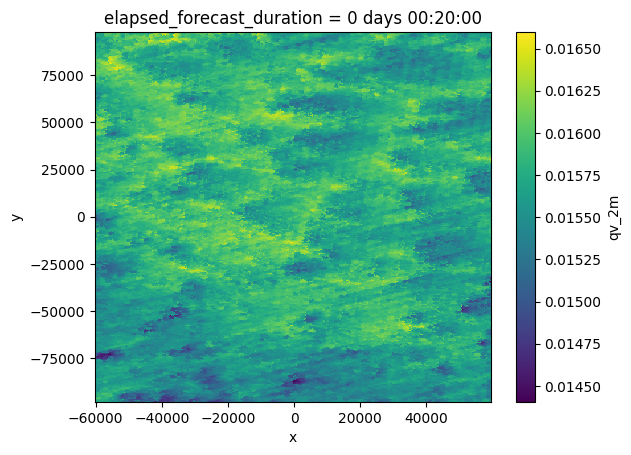

In [11]:
mllam_regridded.qv_2m.isel(start_time=10, elapsed_forecast_duration=1).plot()

In [12]:
def calculate_energy_spectra(data):
    """Calculate the energy spectra of the given data using 2D FFT.

    Parameters
    ----------
    data : xarray.DataArray
        The data for which the energy spectra should be calculated.
        Expected dimensions must include 'x' and 'y', other dimensions will be handled automatically.

    Returns
    -------
    wavenumber : np.ndarray
        The isotropic wavenumbers.
    power : np.ndarray
        The power spectrum averaged over all non-spatial dimensions.
    effective_resolution : float
        The effective resolution of the model.
    """
    # Get grid spacing in meters
    dx = abs(float(data.x[1] - data.x[0]))
    dy = abs(float(data.y[1] - data.y[0]))

    # Identify spatial dimensions
    spatial_dims = ["y", "x"]

    # Move spatial dimensions to the end
    other_dims = [dim for dim in data.dims if dim not in spatial_dims]
    var_data = data.transpose(*other_dims, *spatial_dims).values

    # Reshape the array to combine all non-spatial dimensions
    shape = var_data.shape
    ny, nx = shape[-2:]

    if len(shape) > 2:
        var_data = var_data.reshape(-1, ny, nx)
    else:
        var_data = var_data[np.newaxis, :, :]

    # Compute 2D FFT
    fft_data = np.fft.fft2(var_data, axes=(-2, -1))
    power_spectrum = (np.abs(fft_data) ** 2).mean(axis=0)

    # Rest of the function remains the same
    # Get wavenumbers
    kx = np.fft.fftfreq(nx, d=dx)
    ky = np.fft.fftfreq(ny, d=dy)

    # Create 2D wavenumber grid
    kxx, kyy = np.meshgrid(kx, ky)
    k_mag = np.sqrt(kxx**2 + kyy**2)

    # Create wavenumber bins for azimuthal averaging
    k_bins = np.logspace(
        np.log10(k_mag[k_mag > 0].min()), np.log10(k_mag.max()), num=50
    )

    # Perform azimuthal averaging
    k_averaged = []
    power_averaged = []

    for i in range(len(k_bins) - 1):
        k_mask = (k_mag >= k_bins[i]) & (k_mag < k_bins[i + 1])
        if k_mask.any():
            k_averaged.append(np.mean(k_mag[k_mask]))
            power_averaged.append(np.mean(power_spectrum[k_mask]))

    # Convert to arrays
    k_averaged = np.array(k_averaged)
    power_averaged = np.array(power_averaged)

    # Calculate effective resolution
    effective_resolution = 1 / (4 * dx)

    # Remove first and last two wavenumbers
    return k_averaged[2:-2], power_averaged[2:-2], effective_resolution


def calculate_all_spectra(ds_gt, ds_ml, ds_nwp, variables):
    """Calculate and cache all energy spectra, including temporal evolution.

    Parameters
    ----------
    ds_gt : xarray.Dataset
        Ground truth dataset
    ds_ml : xarray.Dataset
        Machine learning model dataset
    ds_nwp : xarray.Dataset
        Numerical weather prediction model dataset
    variables : list
        List of variables to process

    Returns
    -------
    dict
        Nested dictionary containing wavenumbers, spectra and effective resolution
        for each dataset and variable, including temporal evolution
    """
    spectra_cache = {
        "gt": {},
        "ml": {"static": {}, "temporal": {}},
        "nwp": {"static": {}, "temporal": {}} if ds_nwp is not None else None,
    }

    for var in variables:
        if var not in ds_gt or var not in ds_ml:
            continue
        print(f"Calculating spectra for {var}...")

        # Calculate static spectra for ground truth
        k_gt, spec_gt, eff_res = calculate_energy_spectra(ds_gt[var])
        spectra_cache["gt"][var] = (k_gt, spec_gt, eff_res)

        # Calculate temporal spectra for ML model
        forecast_times = ds_ml.elapsed_forecast_duration.values
        ml_temporal = {}
        for time in forecast_times:
            data = ds_ml[var].sel(elapsed_forecast_duration=time)
            k, spec, _ = calculate_energy_spectra(data)
            ml_temporal[time] = (k, spec)

        spectra_cache["ml"]["temporal"][var] = ml_temporal
        spectra_cache["ml"]["static"][var] = calculate_energy_spectra(
            ds_ml[var]
        )

        # Calculate temporal spectra for NWP model if available
        if ds_nwp is not None and var in ds_nwp:
            forecast_times_nwp = ds_nwp.elapsed_forecast_duration.values
            nwp_temporal = {}
            for time in forecast_times_nwp:
                data = ds_nwp[var].sel(elapsed_forecast_duration=time)
                k, spec, _ = calculate_energy_spectra(data)
                nwp_temporal[time] = (k, spec)

            spectra_cache["nwp"]["temporal"][var] = nwp_temporal
            spectra_cache["nwp"]["static"][var] = calculate_energy_spectra(
                ds_nwp[var]
            )

    return spectra_cache

def plot_energy_spectra(spectra_cache, var, level=None, show_legend=False, temporal=False):
    """Plot energy spectra comparison using pre-calculated spectra.

    Parameters
    ----------
    spectra_cache : dict
        Cache containing pre-calculated spectra
    var : str
        Variable name to plot
    level : float, optional
        Vertical level in hPa
    show_legend : bool, optional
        Whether to show the legend (default: False)
    temporal : bool, optional
        Whether to plot temporal evolution (default: False)
    """
    k_gt, spec_gt, eff_res = spectra_cache["gt"][var]
    k_ml, spec_ml, _ = spectra_cache["ml"]["static"][var]


    fig, ax = plt.subplots(figsize=(11, 6.5), dpi=DPI)

    # Plot ground truth spectrum
    ax.loglog(
        k_gt,
        spec_gt,
        color=COLORS["gt"],
        label="Ground Truth",
        linestyle=LINE_STYLES["gt"][0],
        marker=LINE_STYLES["gt"][1],
        markevery=5,
    )

    if temporal:
        # Plot temporal evolution
        forecast_times = list(spectra_cache["ml"]["temporal"][var].keys())
        for time in forecast_times:
            k_ml_t, spec_ml_t = spectra_cache["ml"]["temporal"][var][time]
            ax.loglog(
                k_ml_t,
                spec_ml_t,
                label=f"ML Model Prediction (t={int(time / np.timedelta64(1, 'm'))} min)",
                linestyle=LINE_STYLES["ml_tmp"][0],
                marker=LINE_STYLES["ml_tmp"][1],
                markevery=4,
                alpha=0.5
            )

    # Plot NWP spectrum if available
    if spectra_cache["nwp"] and var in spectra_cache["nwp"]["static"]:
        k_nwp, spec_nwp, _ = spectra_cache["nwp"]["static"][var]
        ax.loglog(
            k_nwp,
            spec_nwp,
            color=COLORS["nwp"],
            label="NWP Model Prediction",
            linestyle=LINE_STYLES["nwp"][0],
            marker=LINE_STYLES["nwp"][1],
            markevery=3,
        )

    # Plot ML spectrum
    ax.loglog(
        k_ml,
        spec_ml,
        color=COLORS["ml"],
        label="ML Model Prediction (Avg)",
        linestyle=LINE_STYLES["ml"][0],
        marker=LINE_STYLES["ml"][1],
        markevery=4,
    )

    # Plot effective resolution
    ax.axvline(
        eff_res,
        color="salmon",
        linestyle="--",
        label="Effective Model Resolution",
    )

    # Add LSD metric
    spec_nwp = (
        spectra_cache["nwp"]["static"][var][1]
        if spectra_cache["nwp"] and var in spectra_cache["nwp"]["static"]
        else None
    )
    add_lsd_to_plot(ax, spec_gt, spec_ml, spec_nwp)

    # Customize plot
    ax.set_xlabel("Wavenumber (1/m)")
    unit = VARIABLE_UNITS.get(var, "")
    ax.set_ylabel(f"Energy Density (({unit})² * m)")
    title = f"Energy Spectra Comparison for {var}"
    if level is not None:
        title += f" at Level {level} hPa"
    ax.set_title(title)
    if show_legend:
        ax.legend(loc='upper right')
    ax.grid(True, which="both", ls="--", alpha=0.5)

    # Save and display plot
    plot_name = f"energy_spectra_{var}"
    if level is not None:
        plot_name += f"_level_{level}"
    plt.tight_layout()
    plt.show()


def display_lsd_table(spectra_cache, variables, name, caption=""):
    """Display and export LSD metrics table using pre-calculated spectra.

    Parameters
    ----------
    spectra_cache : dict
        Cache containing pre-calculated spectra
    variables : list
        List of variables to analyze
    name : str
        Name for exported files
    caption : str, optional
        Caption for LaTeX table
    """
    lsd_data = {var: {"ML": None, "NWP": None} for var in variables}

    for var in variables:
        if (
            var not in spectra_cache["gt"]
            or var not in spectra_cache["ml"]["static"]
        ):
            continue

        spec_gt = spectra_cache["gt"][var][1]
        spec_ml = spectra_cache["ml"]["static"][var][1]
        spec_nwp = (
            spectra_cache["nwp"]["static"][var][1]
            if spectra_cache["nwp"] and var in spectra_cache["nwp"]["static"]
            else None
        )

        lsd_ml, lsd_nwp = calculate_log_spectral_distance(
            spec_gt, spec_ml, spec_nwp
        )
        lsd_data[var]["ML"] = lsd_ml
        if lsd_nwp is not None:
            lsd_data[var]["NWP"] = lsd_nwp

    df = pd.DataFrame(lsd_data).T

    # Display styled table
    styled_df = df.style.format(
        lambda x: f"{x:.3f}" if pd.notnull(x) else "-"
    ).map(
        lambda x: f"color: {'green' if x < 1 else 'orange' if x < 2 else 'red'}"
        if pd.notnull(x)
        else ""
    )
    display(styled_df)

    # Export raw dataframe
    export_table(df, name, caption)


def plot_wavenumber_evolution(
    spectra_cache,
    ds_ml,
    ds_nwp,
    variables,
    wavenumbers=[1e-2, 5e-2, 1e-1],
    level=None,
):
    """Plot wavenumber evolution using pre-calculated temporal spectra.

    Parameters
    ----------
    spectra_cache : dict
        Cache containing pre-calculated spectra including temporal evolution
    ds_ml : xarray.Dataset
        Machine learning model dataset (used only for time coordinates)
    ds_nwp : xarray.Dataset
        Numerical weather prediction model dataset
    variables : list
        List of variables to analyze
    wavenumbers : list, optional
        List of wavenumbers to analyze
    level : float, optional
        Vertical level in hPa
    """
    forecast_times = ds_ml.elapsed_forecast_duration.values

    for var in variables:
        if (
            var not in spectra_cache["gt"]
            or var not in spectra_cache["ml"]["temporal"]
        ):
            continue

        fig, axes = plt.subplots(1, len(wavenumbers), figsize=(24, 8), dpi=DPI)

        for idx, target_k in enumerate(wavenumbers):
            spectra = {
                "gt": [],
                "ml": [],
                "nwp": [] if spectra_cache["nwp"] else [],
            }

            # Get ground truth power for target wavenumber
            k_gt, spec_gt, _ = spectra_cache["gt"][var]
            idx_k_gt = np.abs(k_gt - target_k).argmin()
            gt_power = spec_gt[idx_k_gt]

            for time in forecast_times:
                # Get ML spectra from cache
                k_ml, spec_ml = spectra_cache["ml"]["temporal"][var][time]
                idx_k_ml = np.abs(k_ml - target_k).argmin()
                spectra["ml"].append(spec_ml[idx_k_ml])

                # Get NWP spectra from cache if available
                if (
                    spectra_cache["nwp"]
                    and var in spectra_cache["nwp"]["temporal"]
                    and time in spectra_cache["nwp"]["temporal"][var]
                ):
                    k_nwp, spec_nwp = spectra_cache["nwp"]["temporal"][var][
                        time
                    ]
                    idx_k_nwp = np.abs(k_nwp - target_k).argmin()
                    spectra["nwp"].append(spec_nwp[idx_k_nwp])
                else:
                    spectra["nwp"].append(np.nan)


                spectra["gt"].append(gt_power)

            # Plot evolution for current wavenumber
            hours = forecast_times / np.timedelta64(1, "h")

            # Export table
            # export_table(
            #     pd.DataFrame(
            #         {
            #             key.upper(): values
            #             for key, values in spectra.items()
            #             if values
            #         },
            #         index=hours,
            #     ).rename_axis(
            #         index="Elapsed Forecast Duration (h)",
            #         columns=f"Energy Density (k={target_k:.2e})",
            #     ),
            #     f"wavenumber_evolution_{var}_k{target_k:.2e}",
            # )

            # Plot spectra
            for key, values in spectra.items():
                if not values:
                    continue
                
                if not np.isnan(values).all():
                    axes[idx].plot(
                        hours,
                        values,
                        color=COLORS[key],
                        linestyle=LINE_STYLES[key][0],
                        marker=LINE_STYLES[key][1],
                        label=key.upper(),
                    )

            # Add titles and labels
            axes[idx].set_title(f"k = {target_k:.2f}")
            if idx == len(wavenumbers) // 2:  # Only middle plot gets x-label
                axes[idx].set_xlabel("Elapsed Forecast Duration (h)")
            if idx == 0:
                axes[idx].set_ylabel("Energy Density")
                axes[idx].legend()

        plt.tight_layout()
        plt.show()


def calculate_log_spectral_distance(true_spectrum, ml_spectrum, nwp_spectrum):
    """
    Calculate the Log Spectral Distance between three power spectra
    """
    eps = 1e-10
    log_spec1 = np.log10(true_spectrum + eps)
    log_spec2 = np.log10(ml_spectrum + eps)
    lsd_ml = np.sqrt(np.mean((log_spec1 - log_spec2) ** 2))
    if nwp_spectrum is None:
        return lsd_ml, None
    log_spec3 = np.log10(nwp_spectrum + eps)
    lsd_nwp = np.sqrt(np.mean((log_spec1 - log_spec3) ** 2))
    return lsd_ml, lsd_nwp


def add_lsd_to_plot(ax, true_spectrum, ml_spectrum, nwp_spectrum):
    """
    Add LSD metric as text box to spectrum plot
    """
    if nwp_spectrum is None:
        lsd_nwp = None
        lsd_ml, _ = calculate_log_spectral_distance(
            true_spectrum, ml_spectrum, None
        )
        textstr = f"LSD ML = {lsd_ml:.4f}"
    else:
        lsd_ml, lsd_nwp = calculate_log_spectral_distance(
            true_spectrum, ml_spectrum, nwp_spectrum
        )
        textstr = f"LSD NWP = {lsd_nwp:.4f}, LSD ML = {lsd_ml:.4f}"
    props = dict(boxstyle="round", facecolor="wheat", alpha=0.5)
    ax.text(
        0.05,
        0.1,
        textstr,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=props,
    )

In [26]:
spectra_cache = calculate_all_spectra(
    gt_regridded, mllam_regridded, None, variables=["t_2m", "u_10m", "v_10m", "qv_2m", "tqc_dia", "pres_sfc"]
)

Calculating spectra for t_2m...
Calculating spectra for u_10m...
Calculating spectra for v_10m...
Calculating spectra for qv_2m...
Calculating spectra for tqc_dia...
Calculating spectra for pres_sfc...


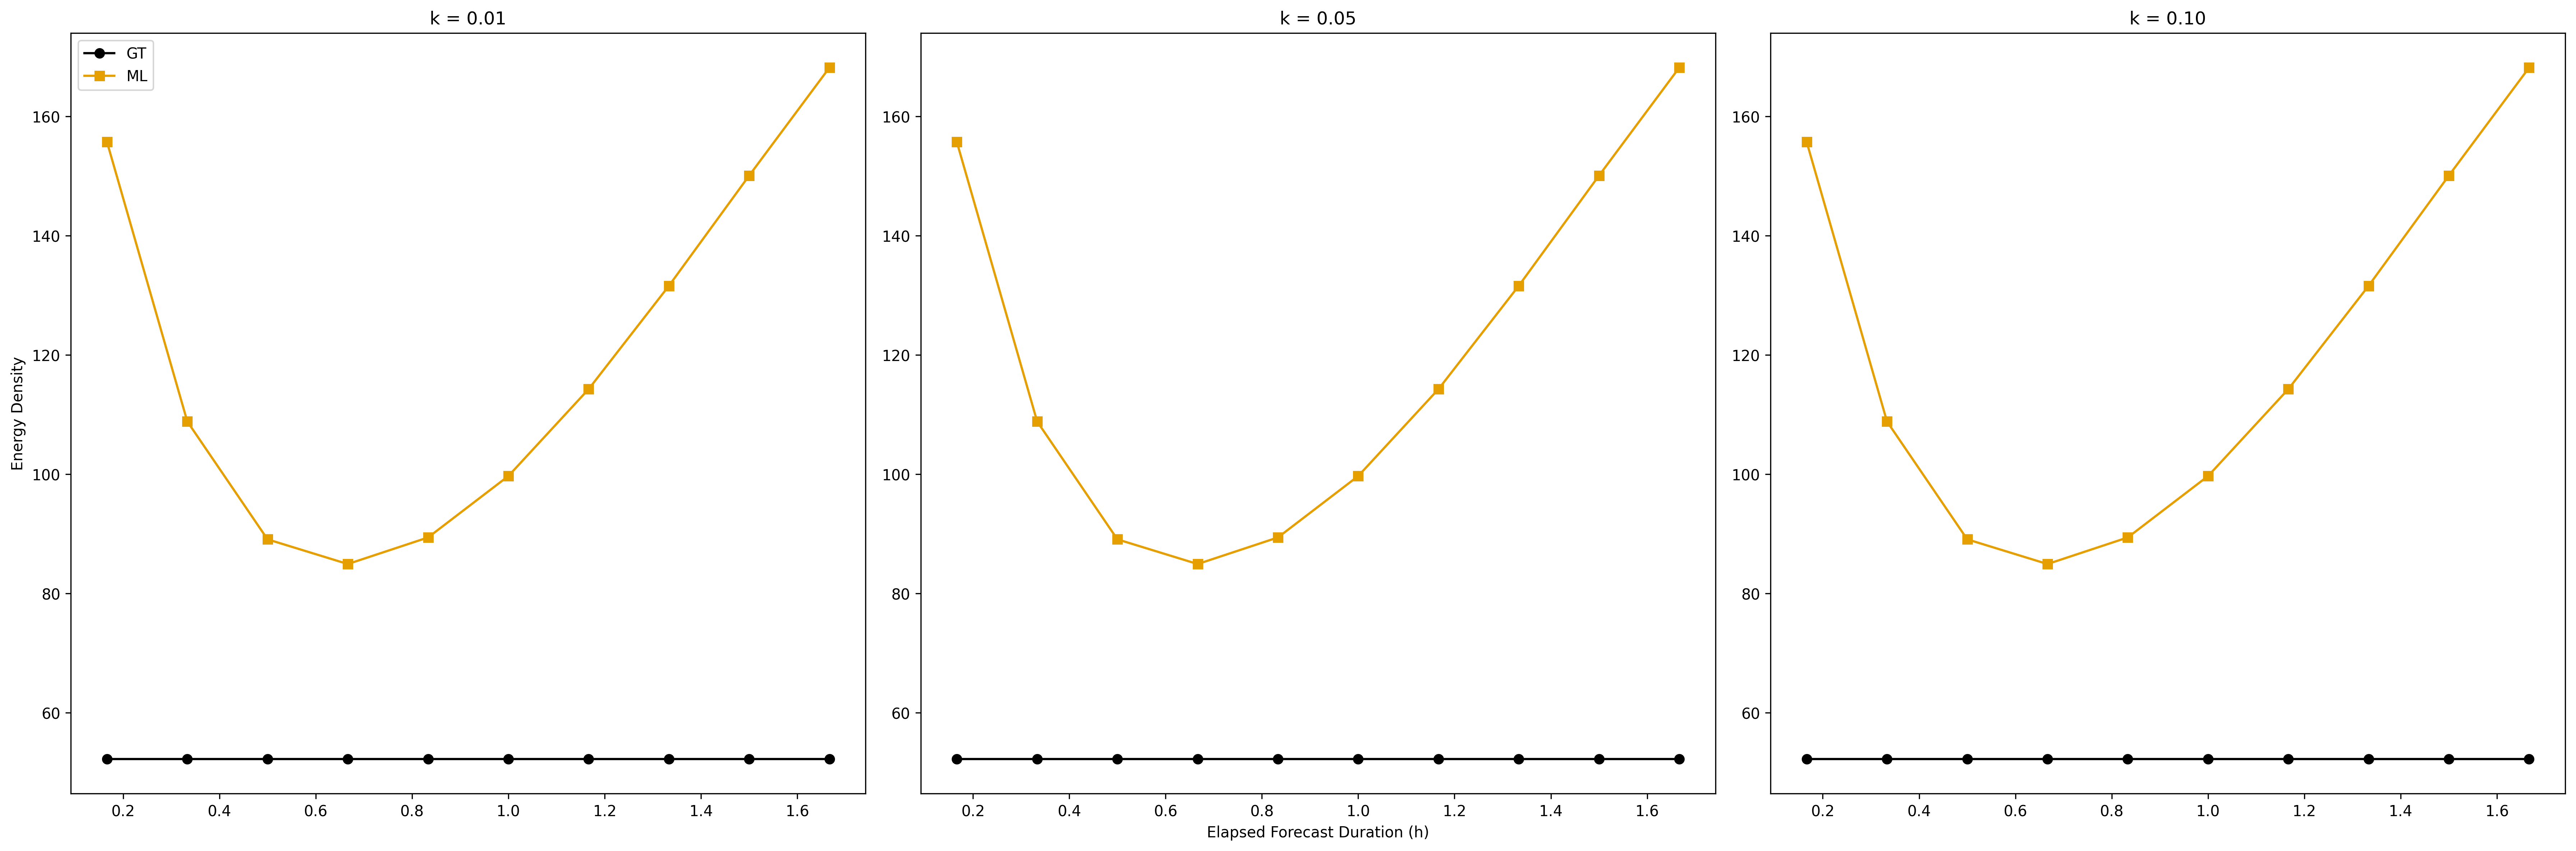

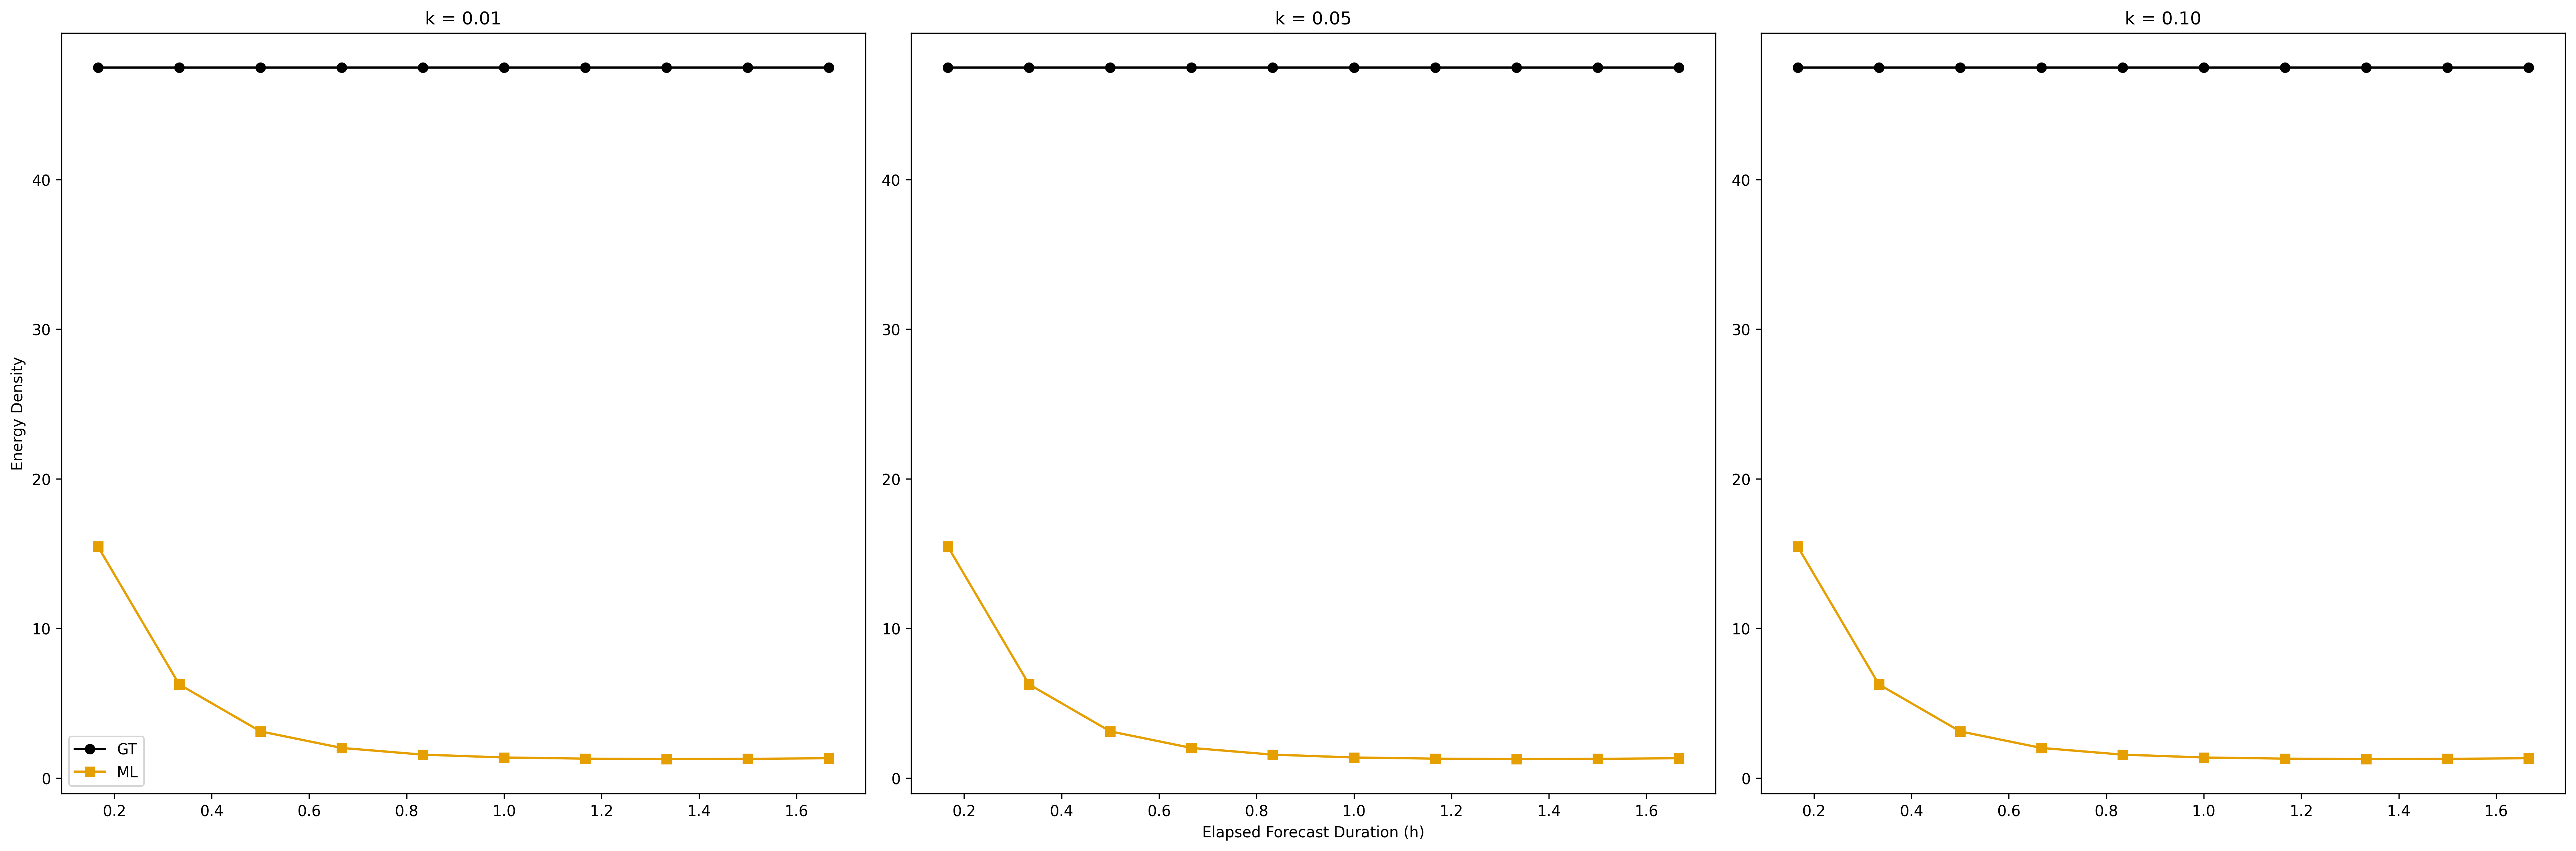

In [ ]:
DPI = 300
COLORS = {
    "gt": "#000000",  # Black
    "ml": "#E69F00",  # Orange
    "nwp": "#56B4E9",  # Light blue
    "error": "#CC79A7",  # Pink
}

# Line styles and markers for accessibility
LINE_STYLES = {
    "gt": ("solid", "o"),
    "ml": ("solid", "s"),
    "nwp": ("dotted", "^"),
    "ml_tmp": ("dashed", "x"),
}

VARIABLE_UNITS = {
    # Surface and near-surface variables
    "t_2m": "K",

}

plot_wavenumber_evolution(
    spectra_cache, mllam_regridded, None, variables=["t_2m", "tqc_dia"]
    )

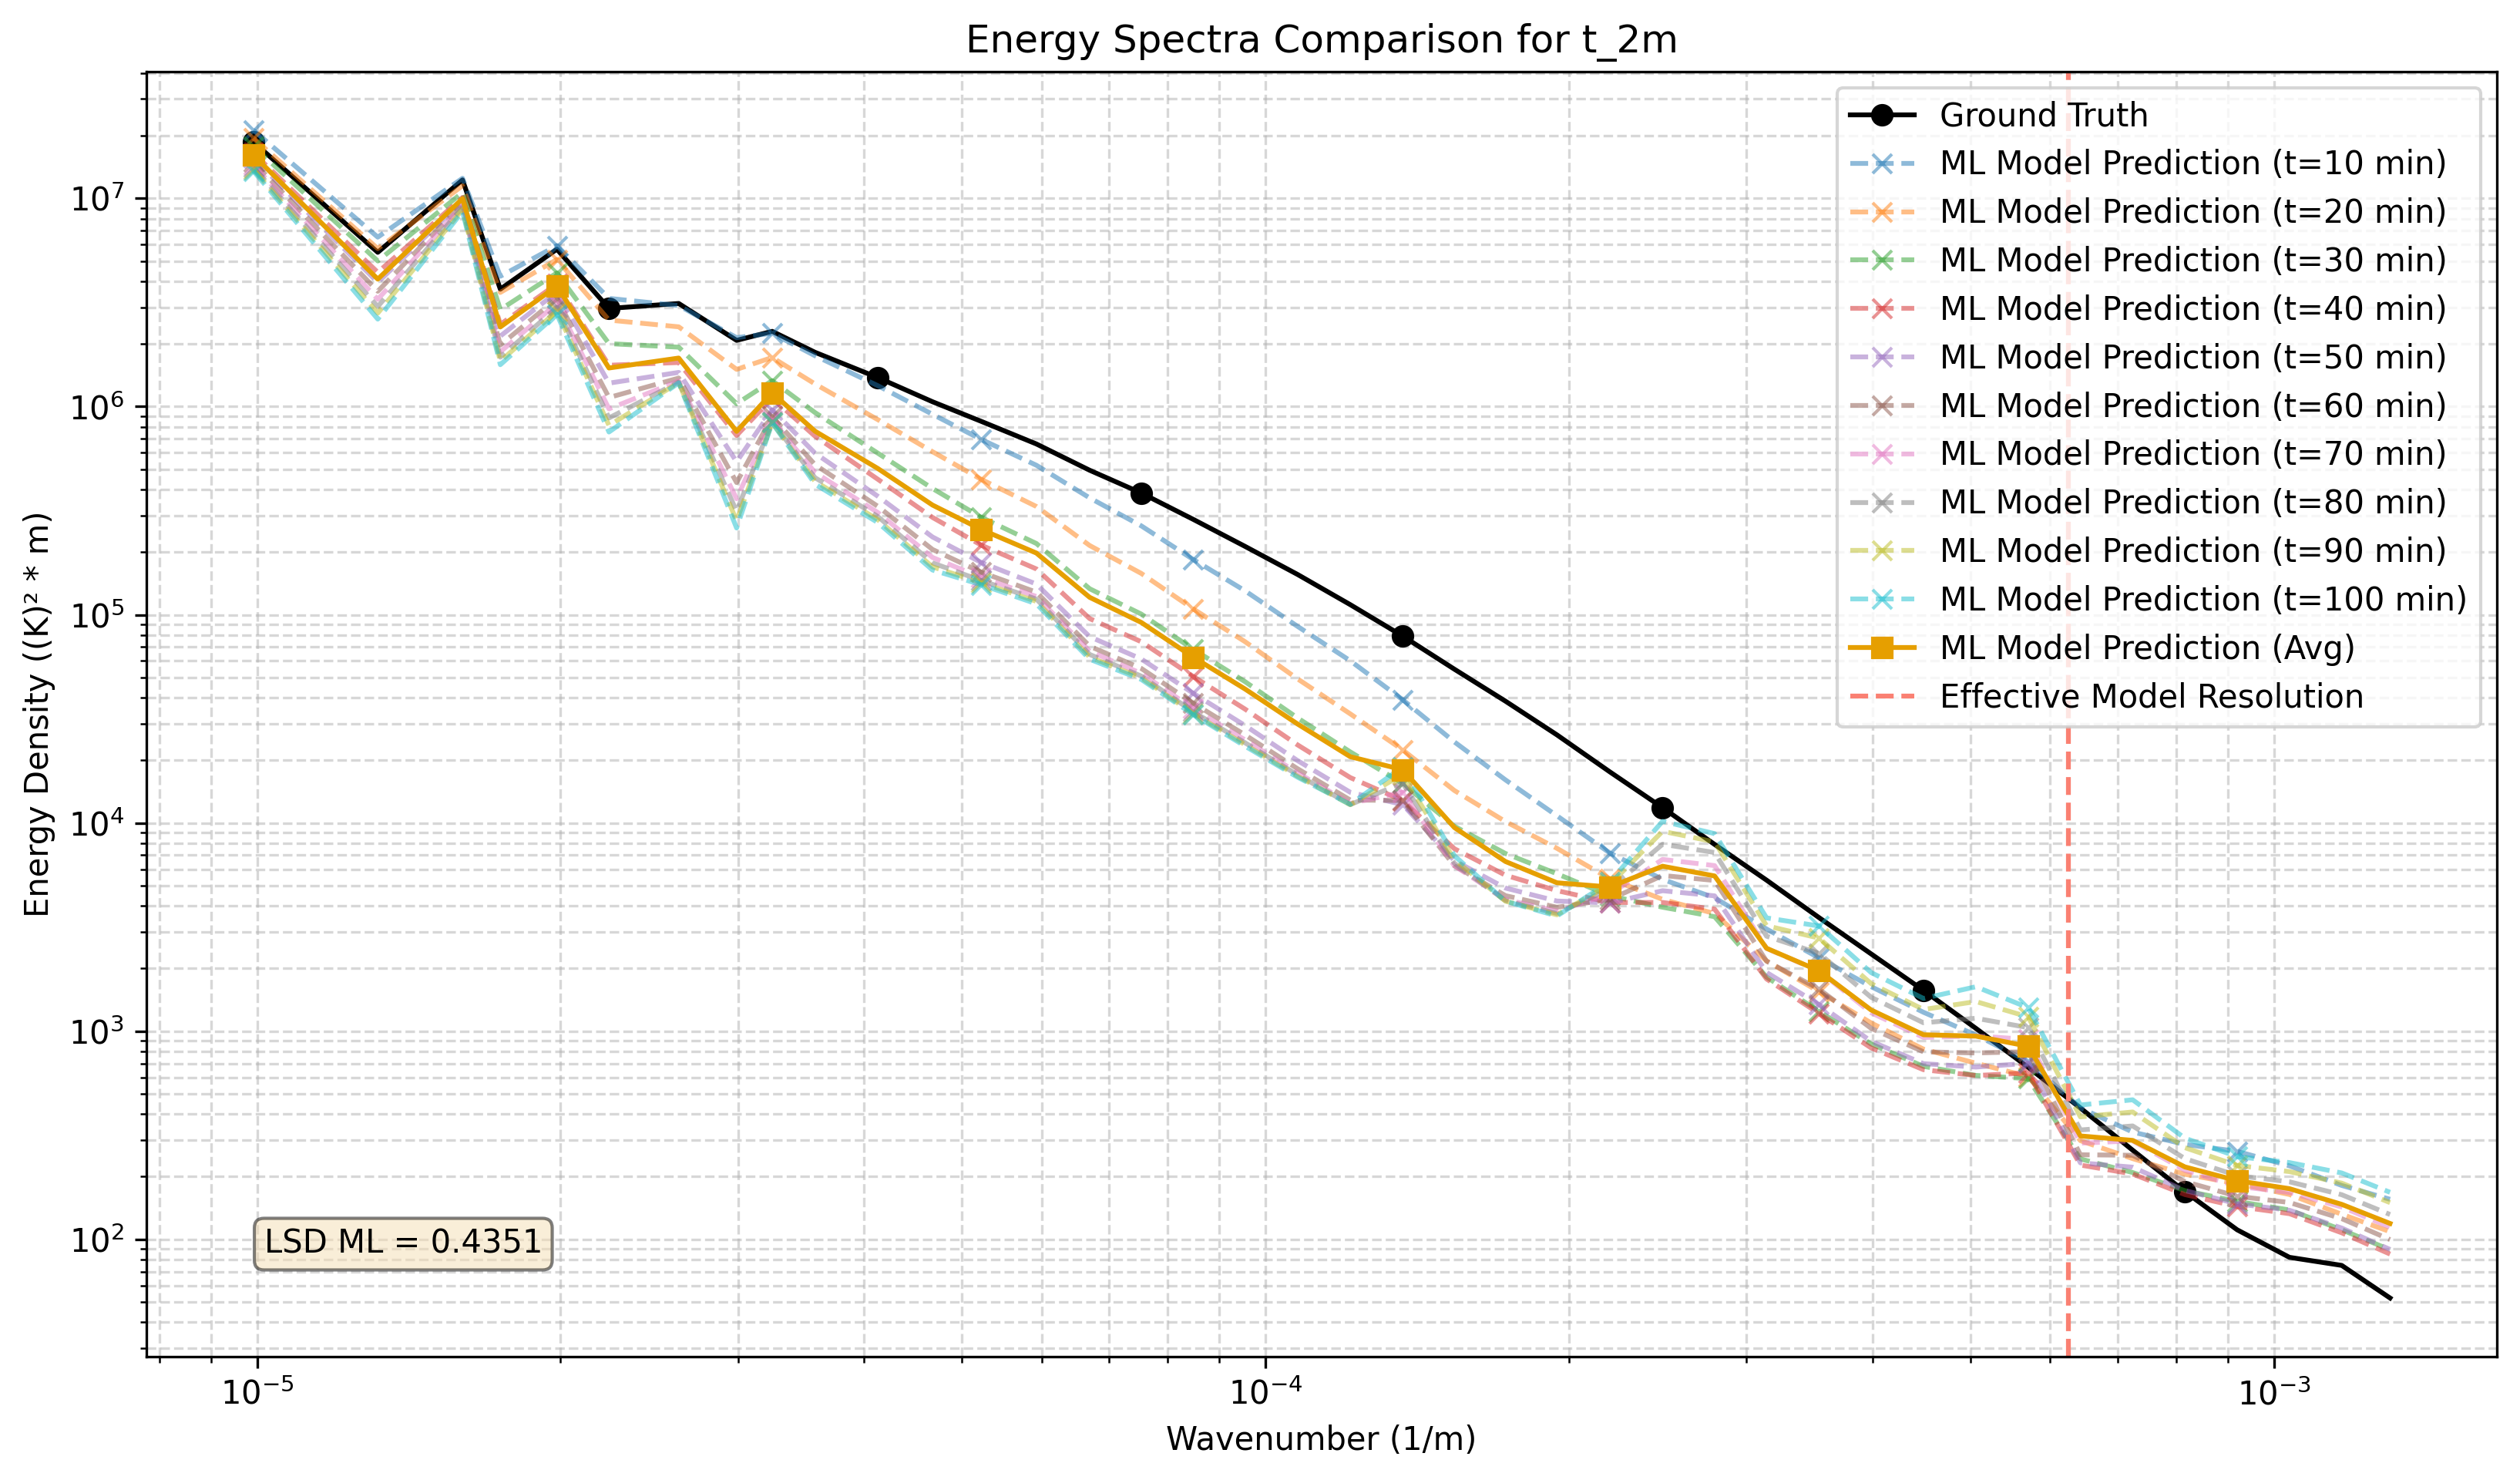

In [17]:
plot_energy_spectra(spectra_cache, "t_2m", show_legend=True, temporal=True)

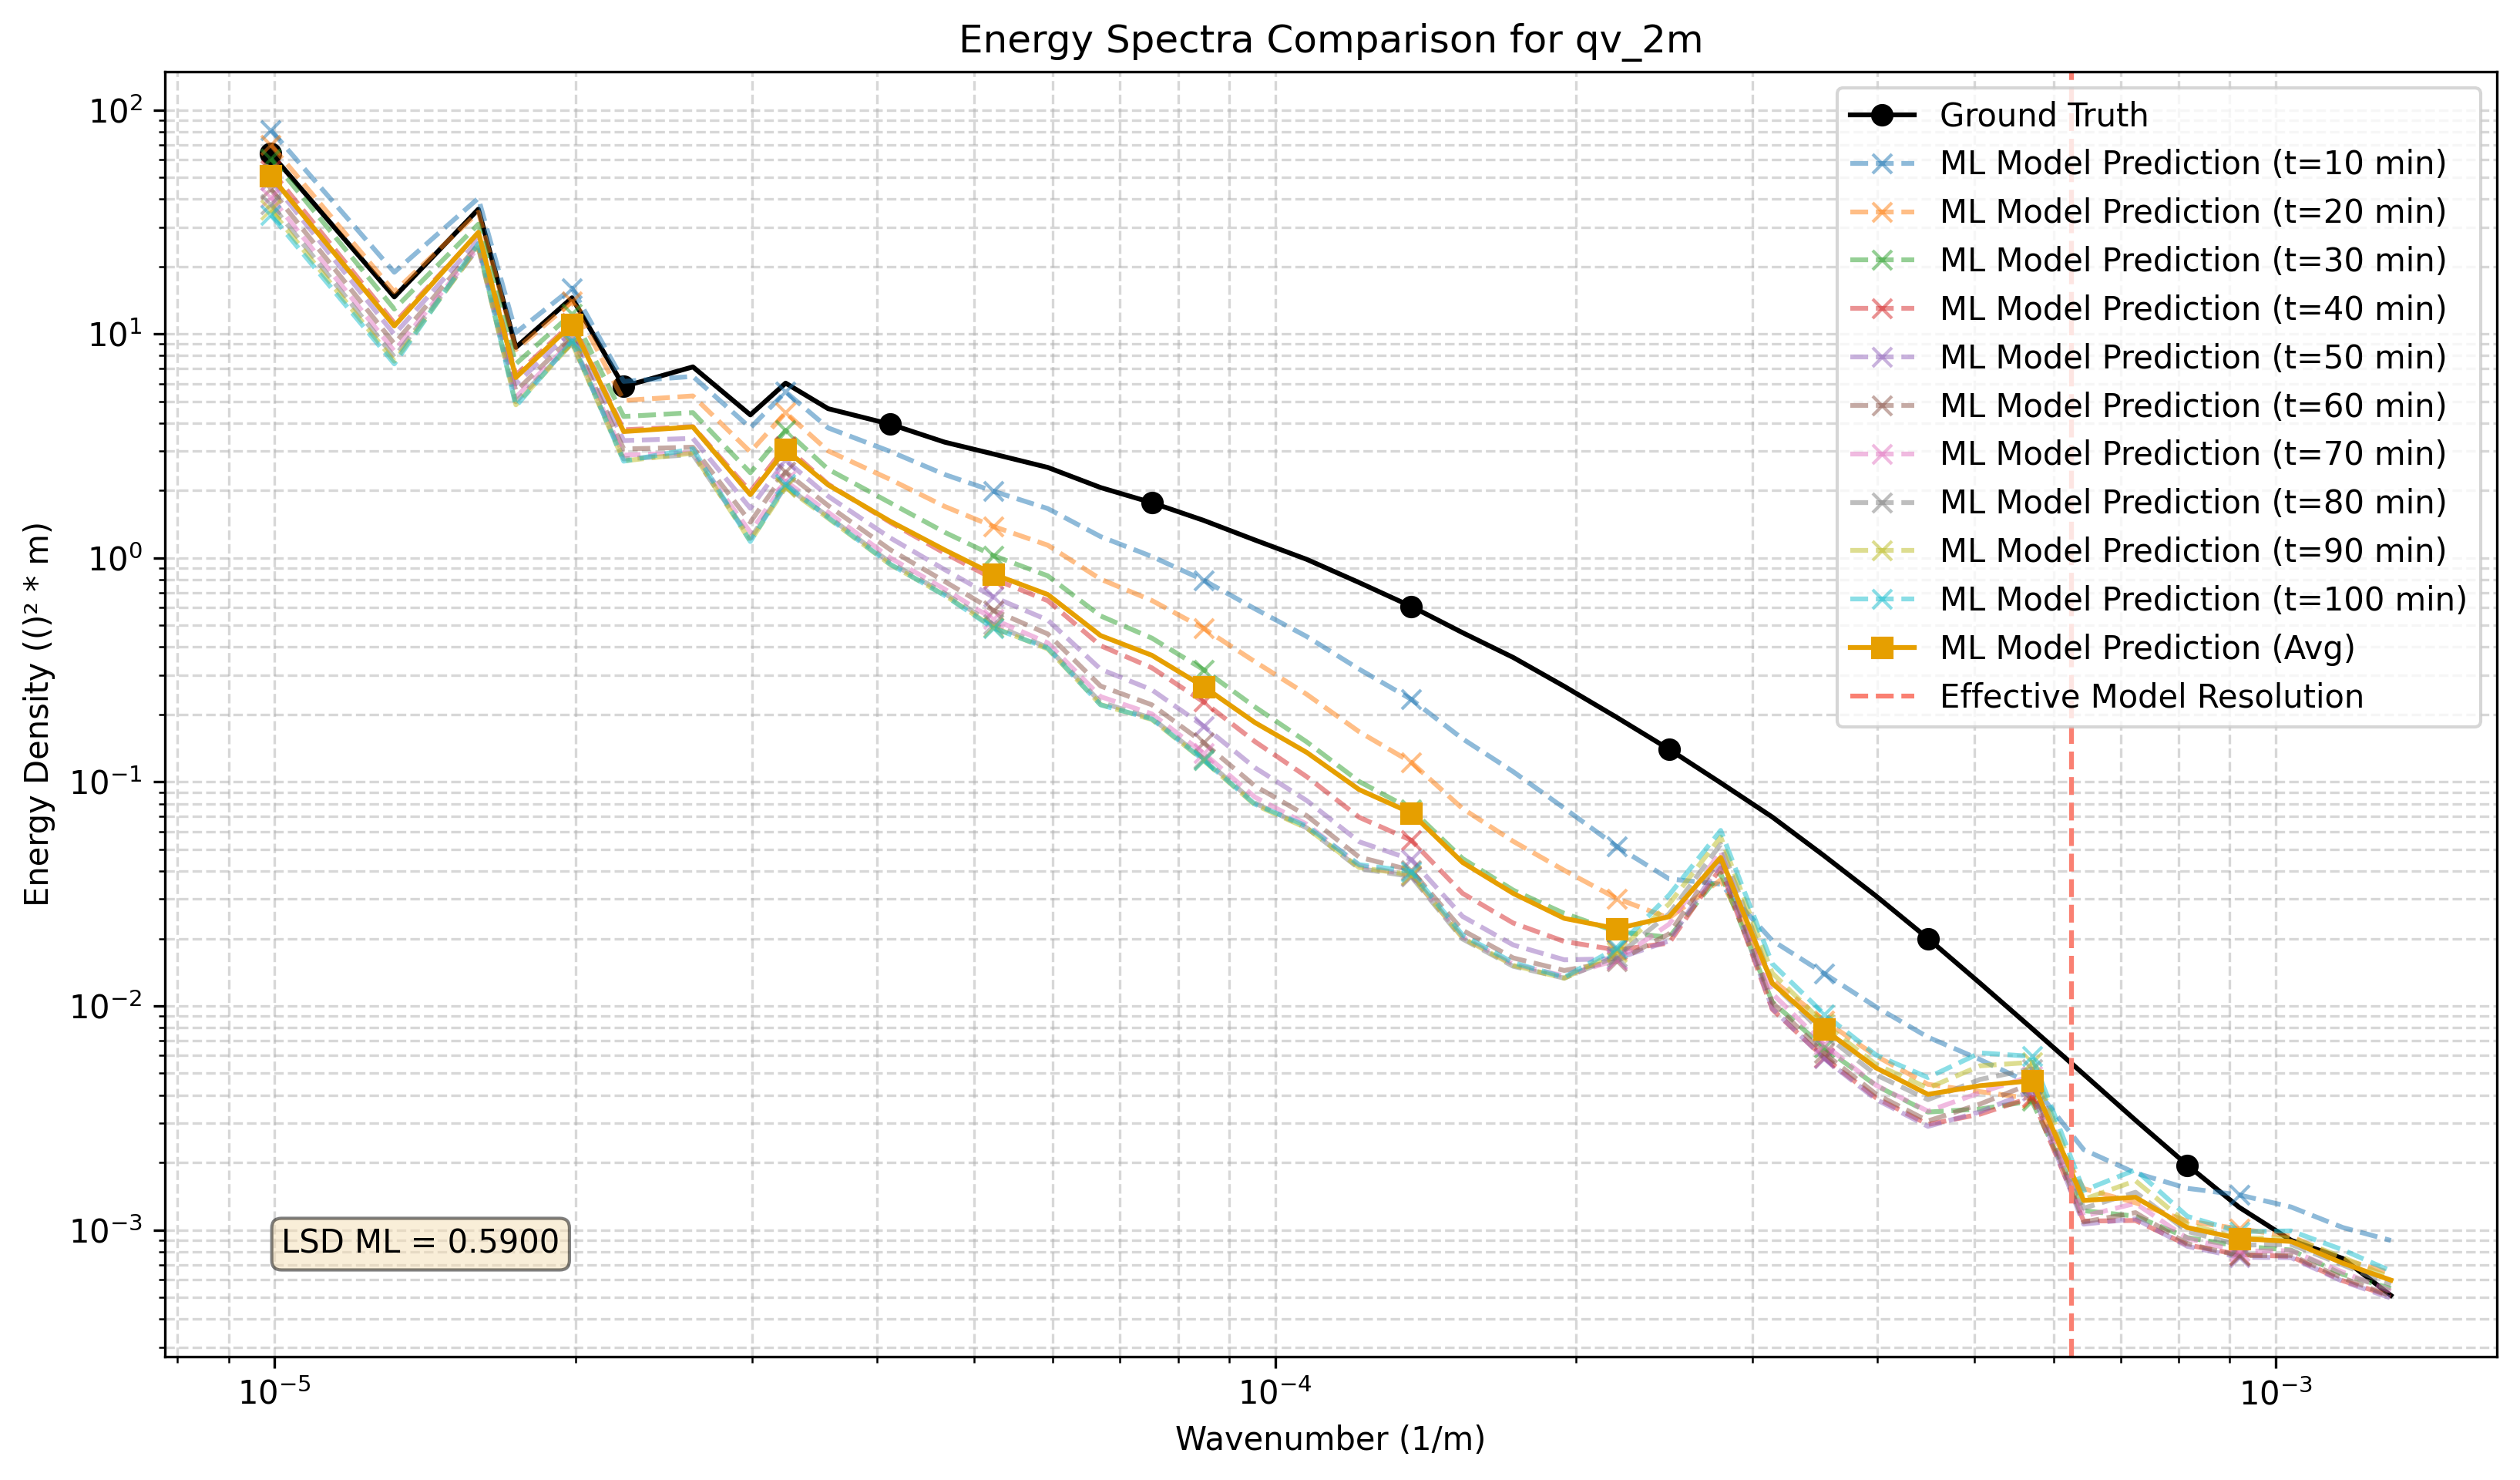

In [18]:
plot_energy_spectra(spectra_cache, "qv_2m", show_legend=True, temporal=True)

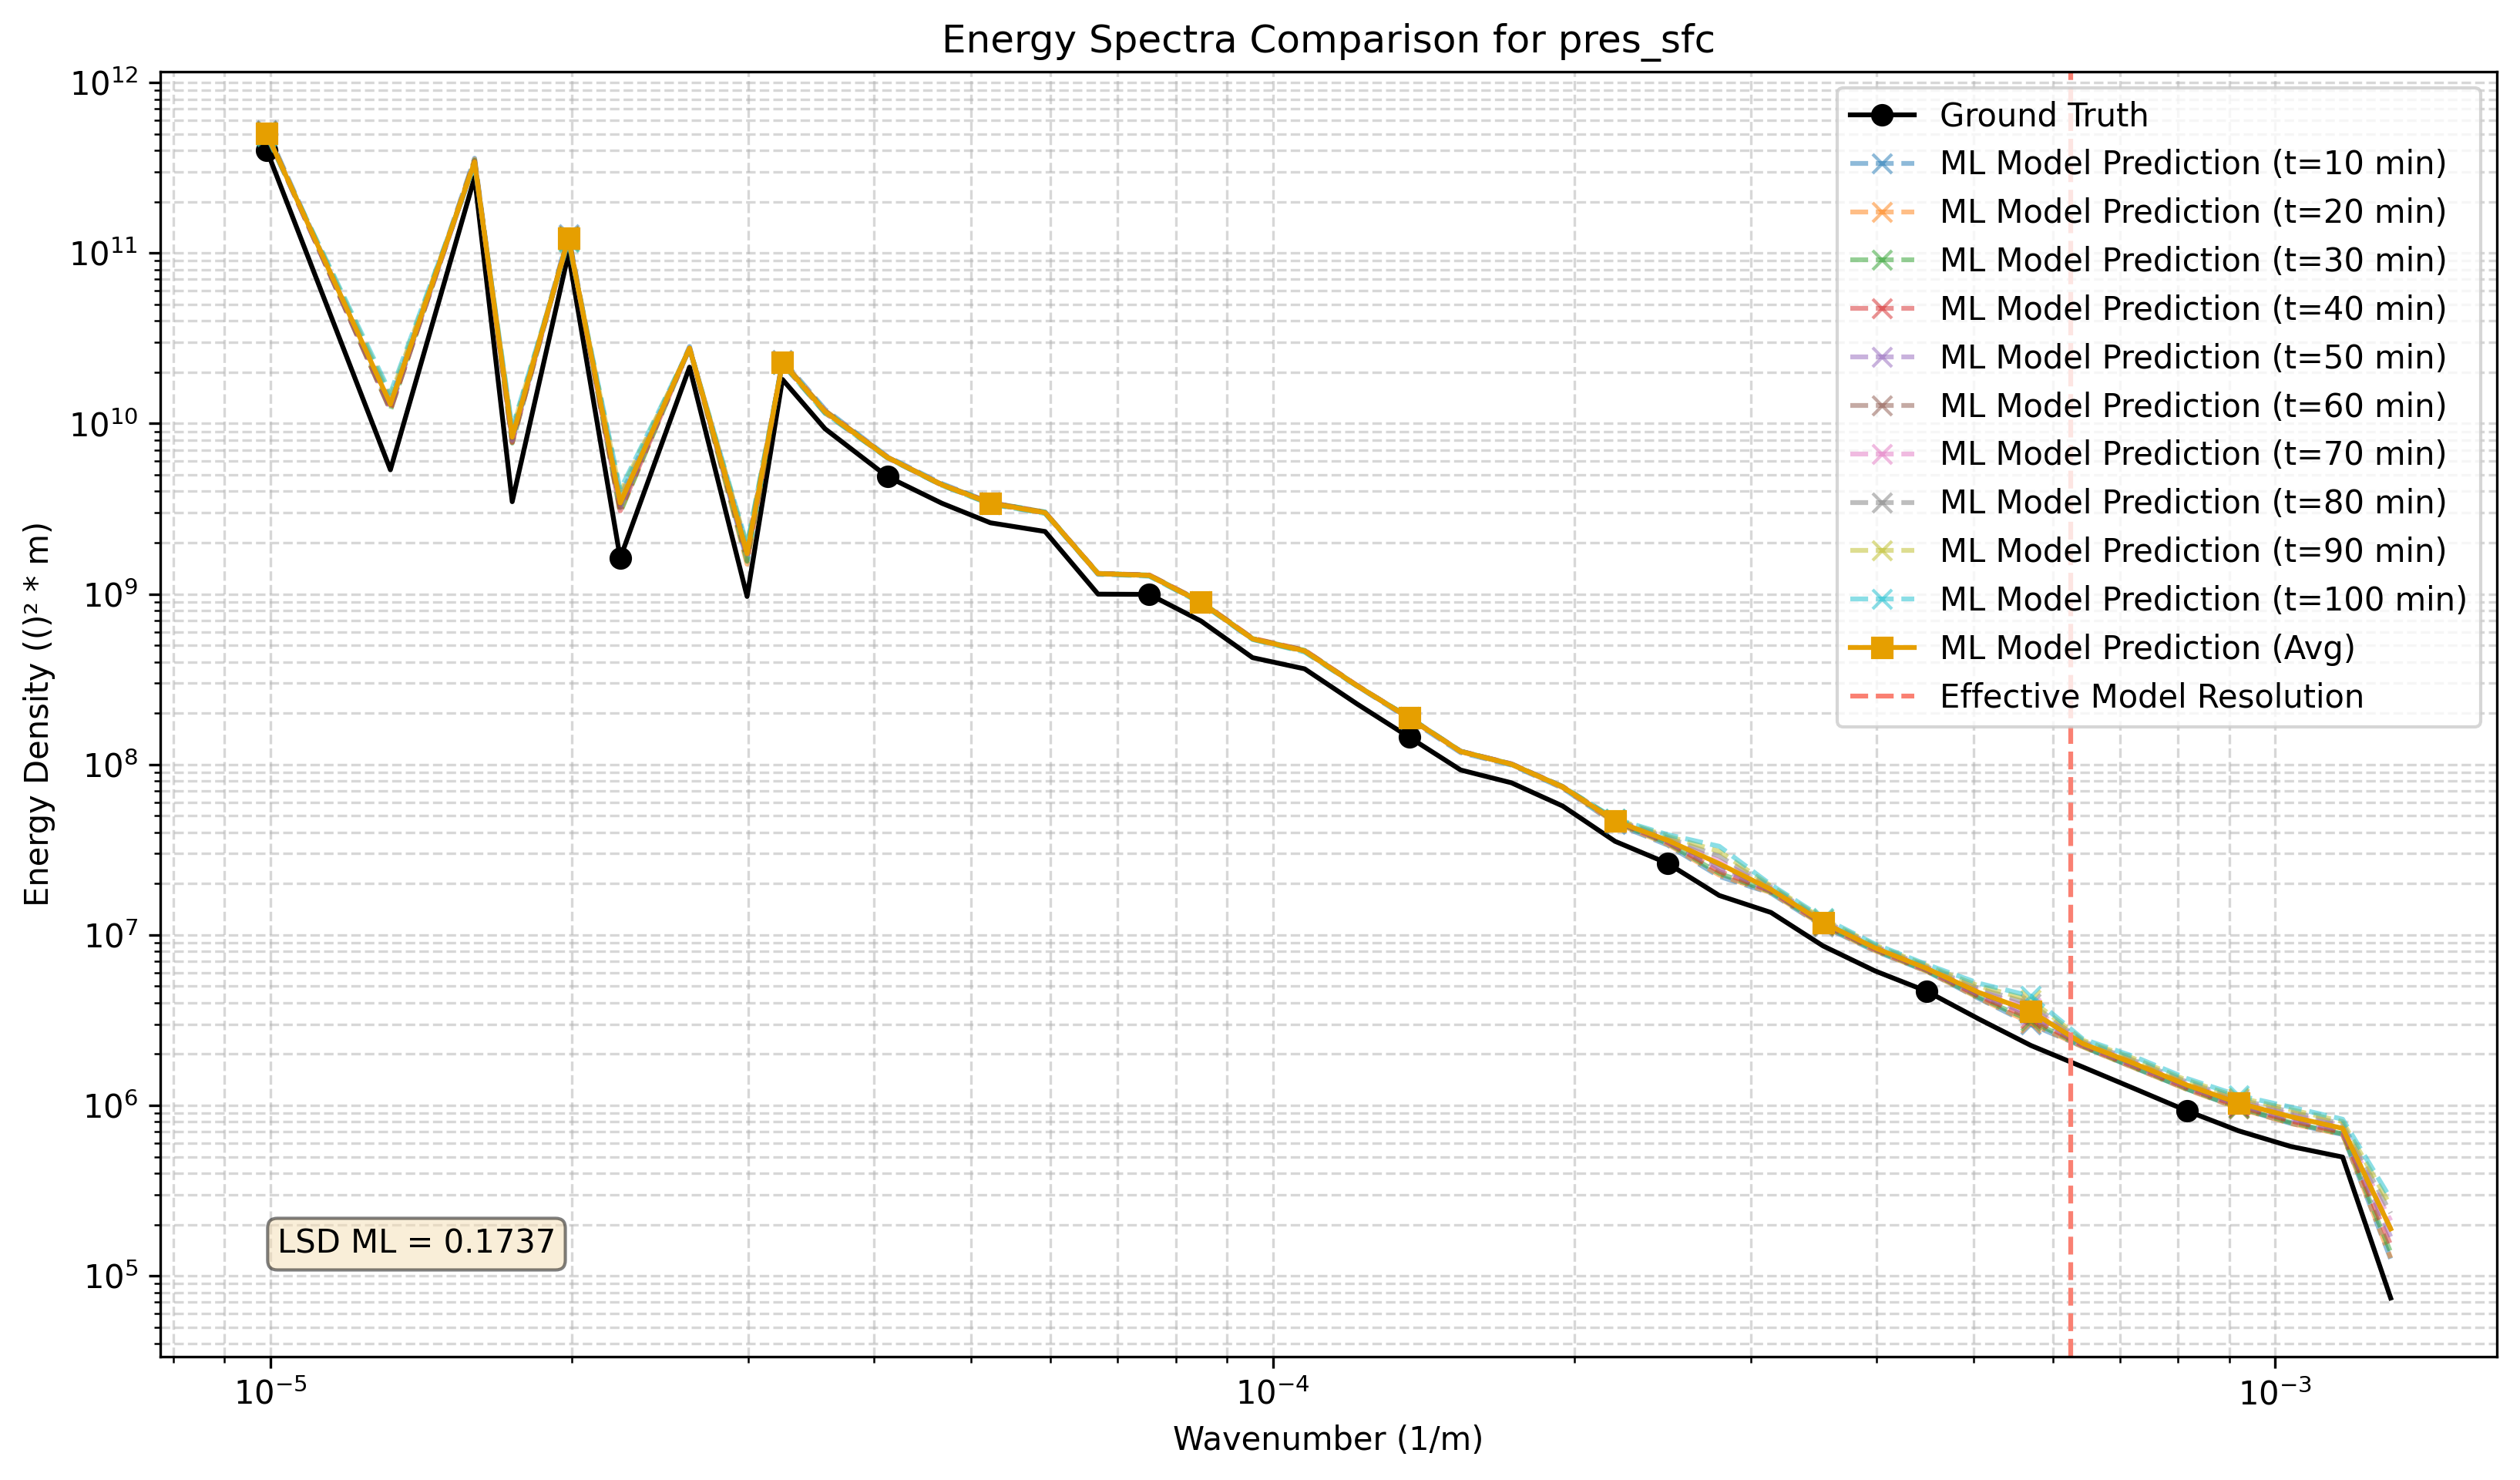

In [22]:
plot_energy_spectra(spectra_cache, "pres_sfc", show_legend=True, temporal=True)

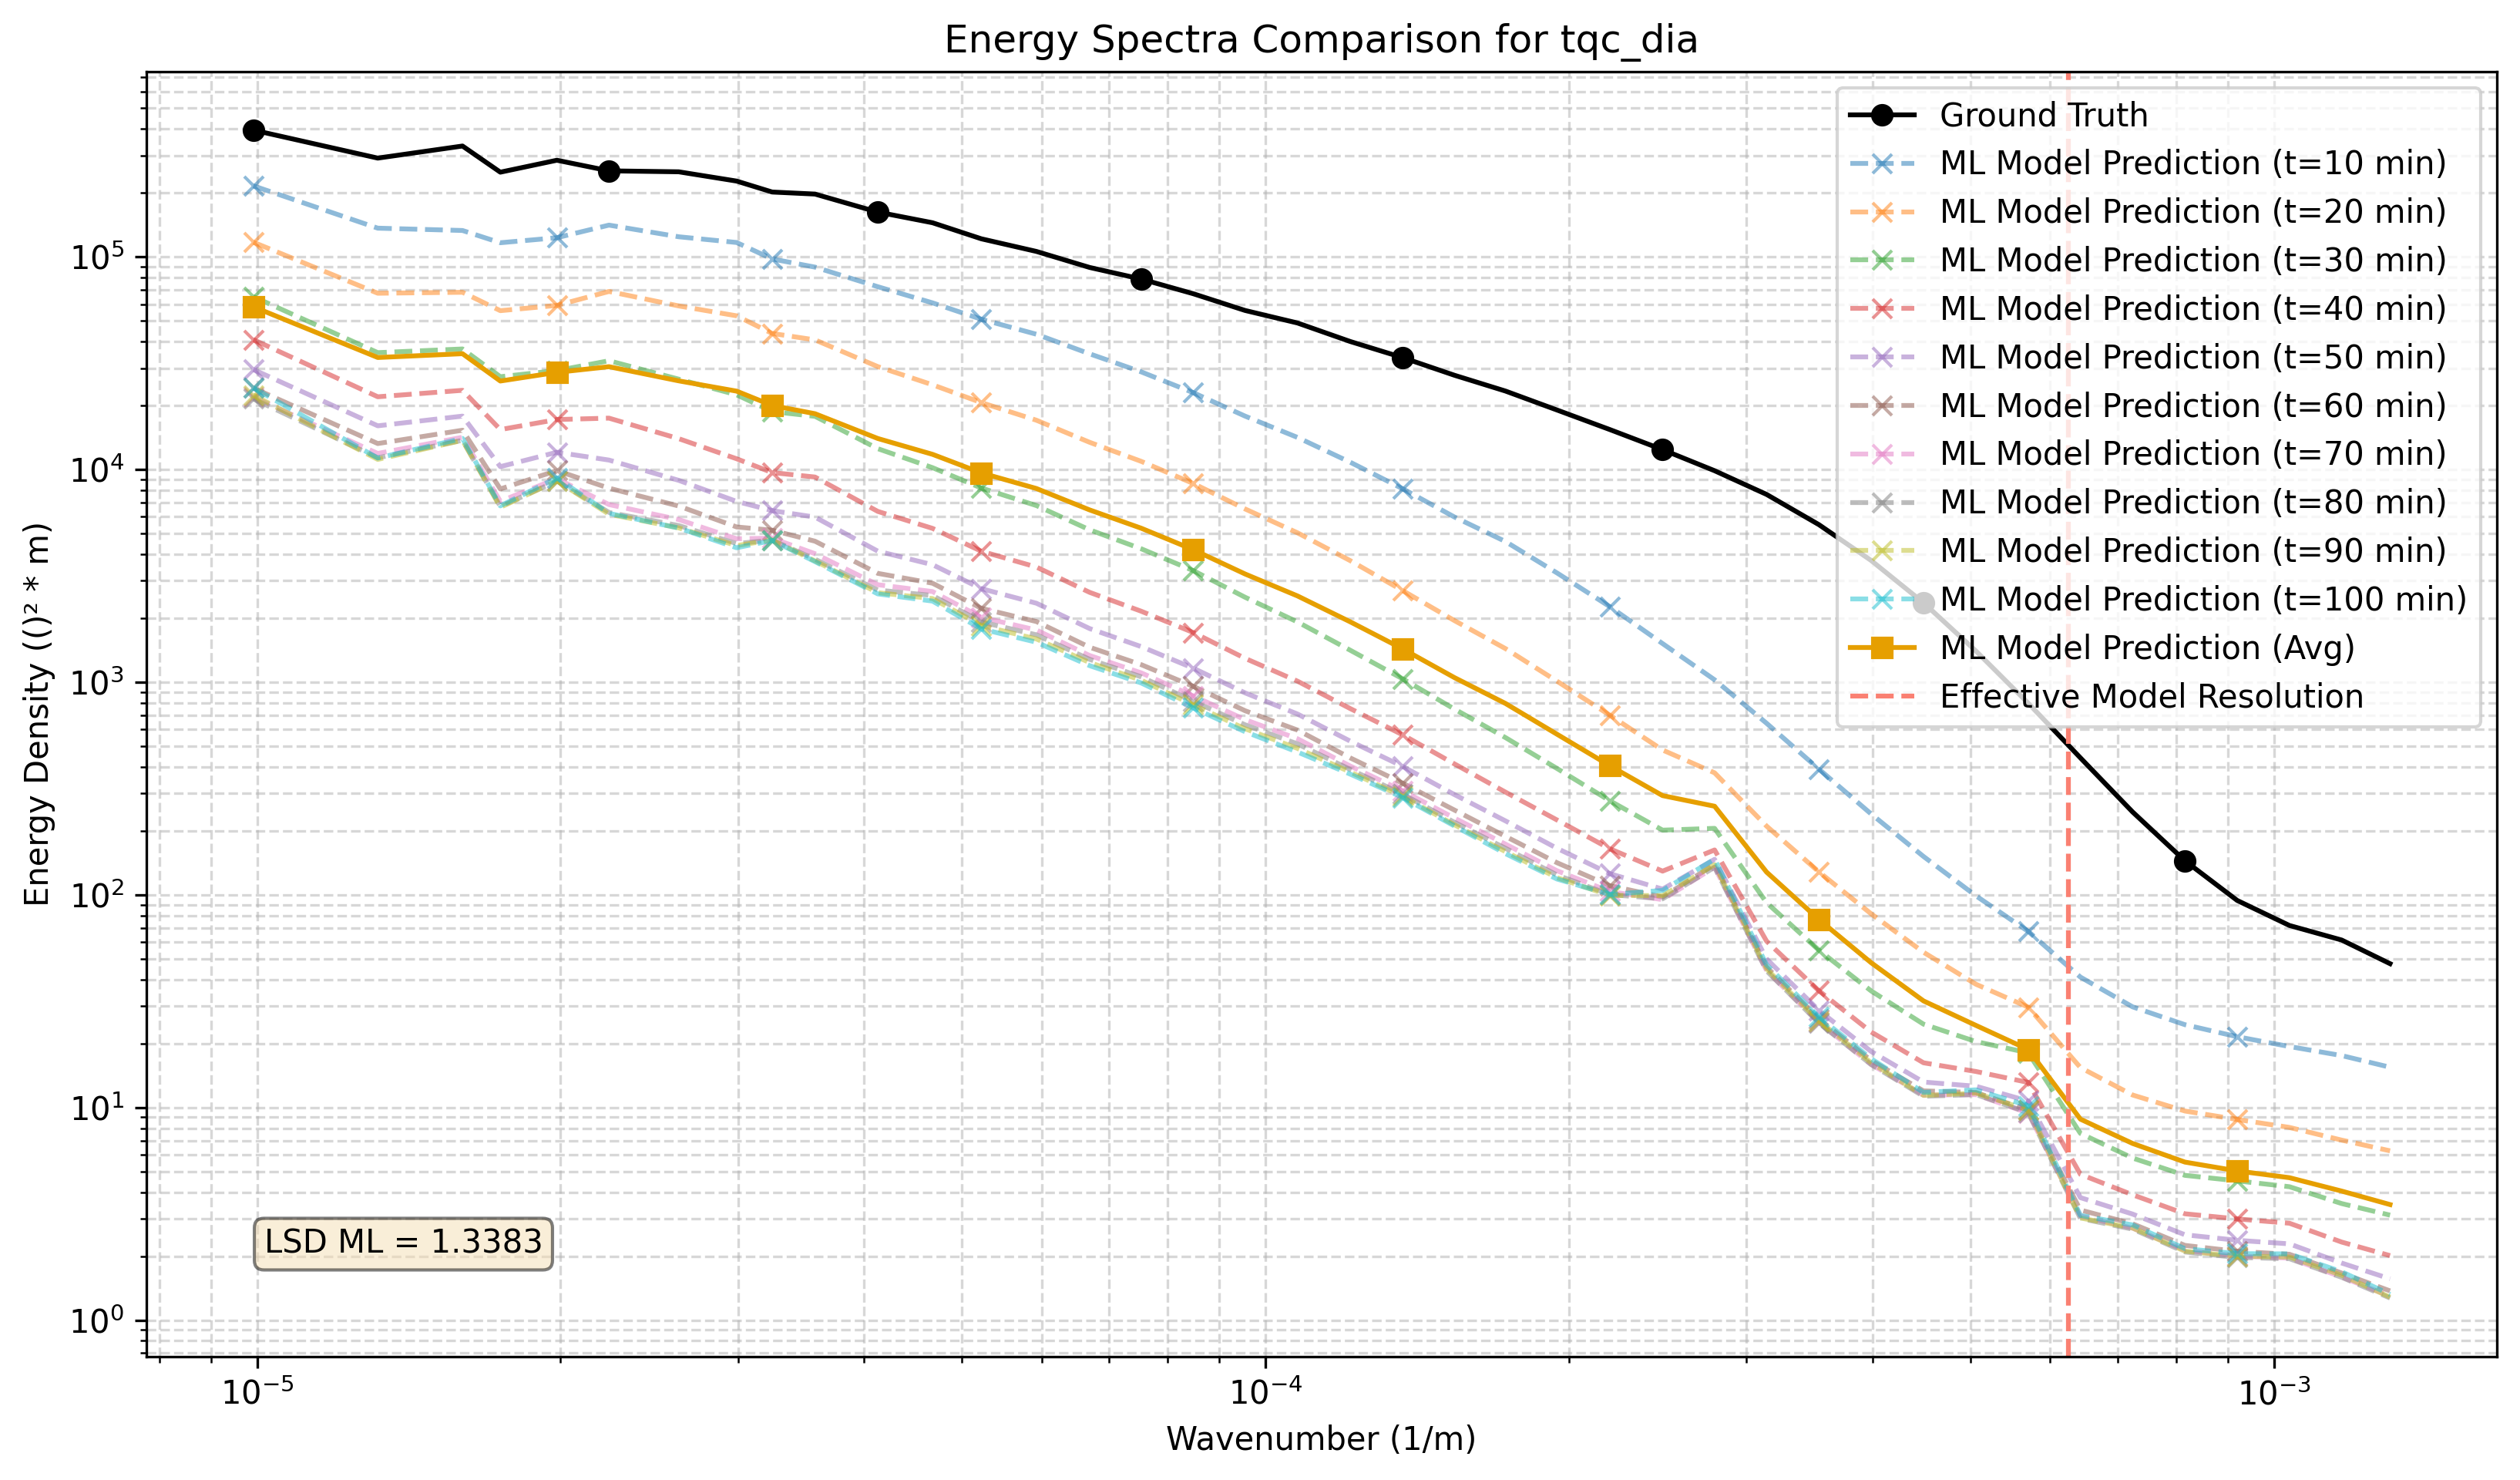

In [24]:
plot_energy_spectra(spectra_cache, "tqc_dia", show_legend=True, temporal=True)

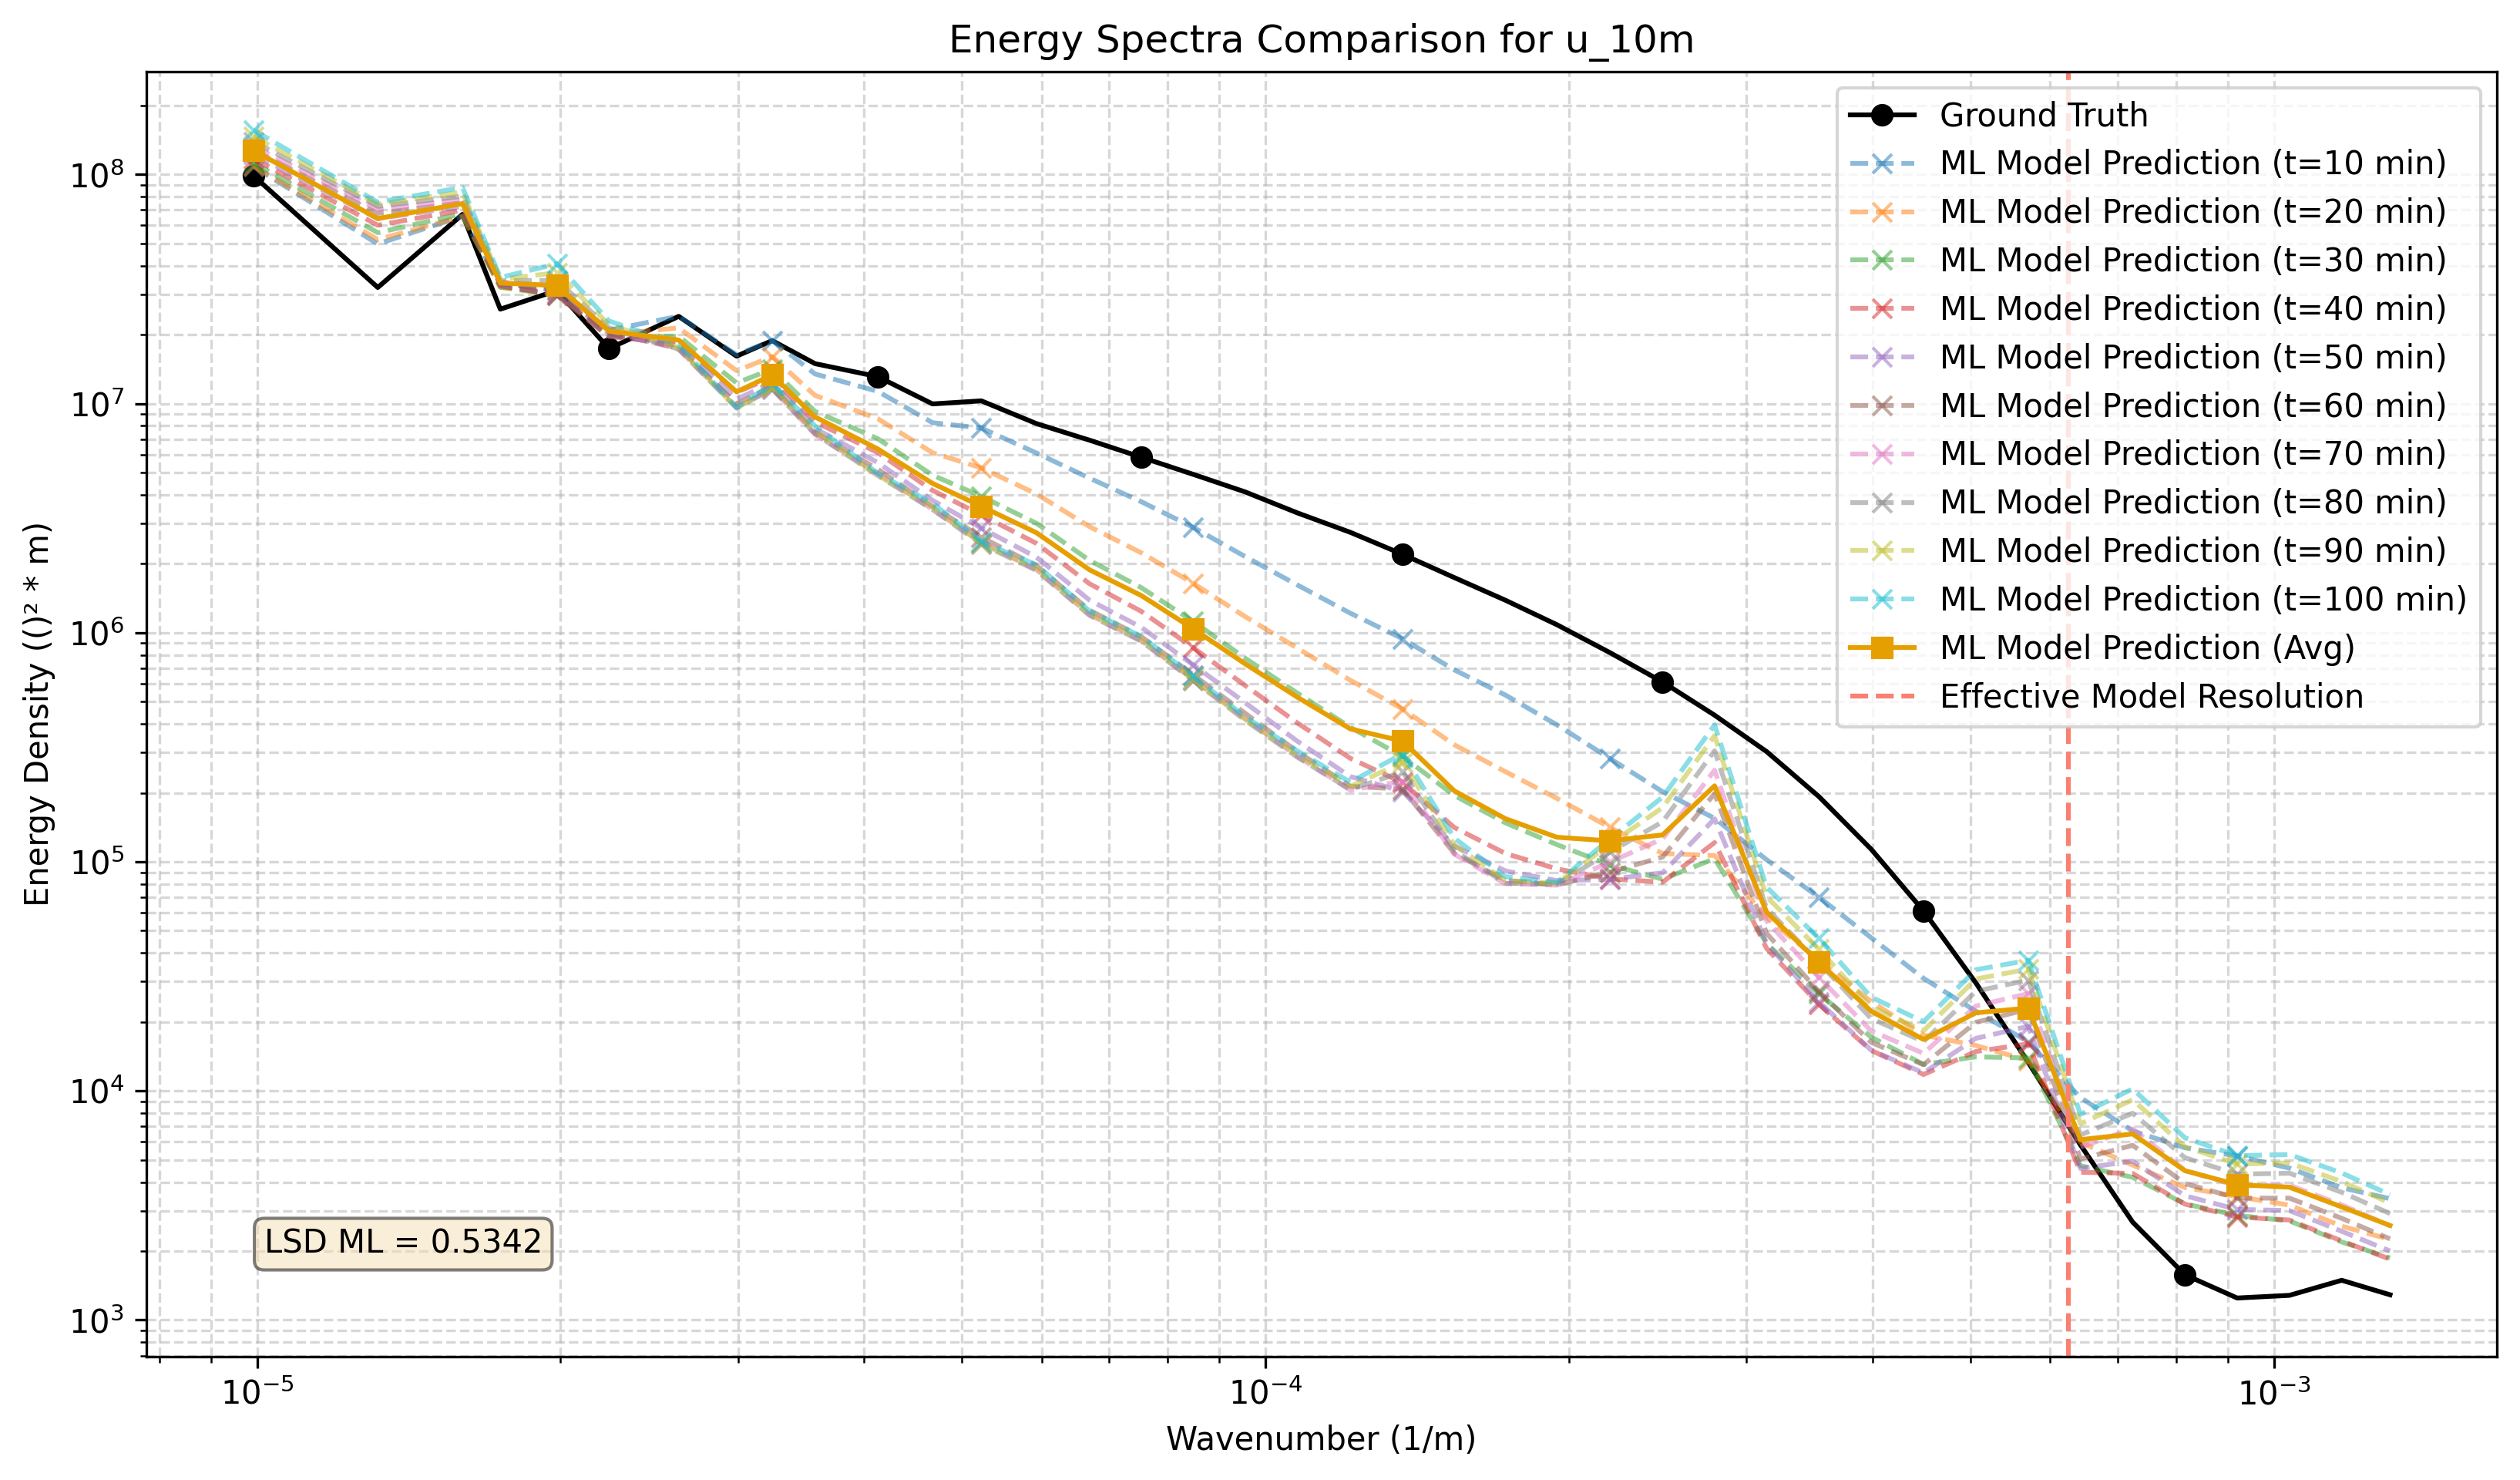

In [27]:
plot_energy_spectra(spectra_cache, "u_10m", show_legend=True, temporal=True)

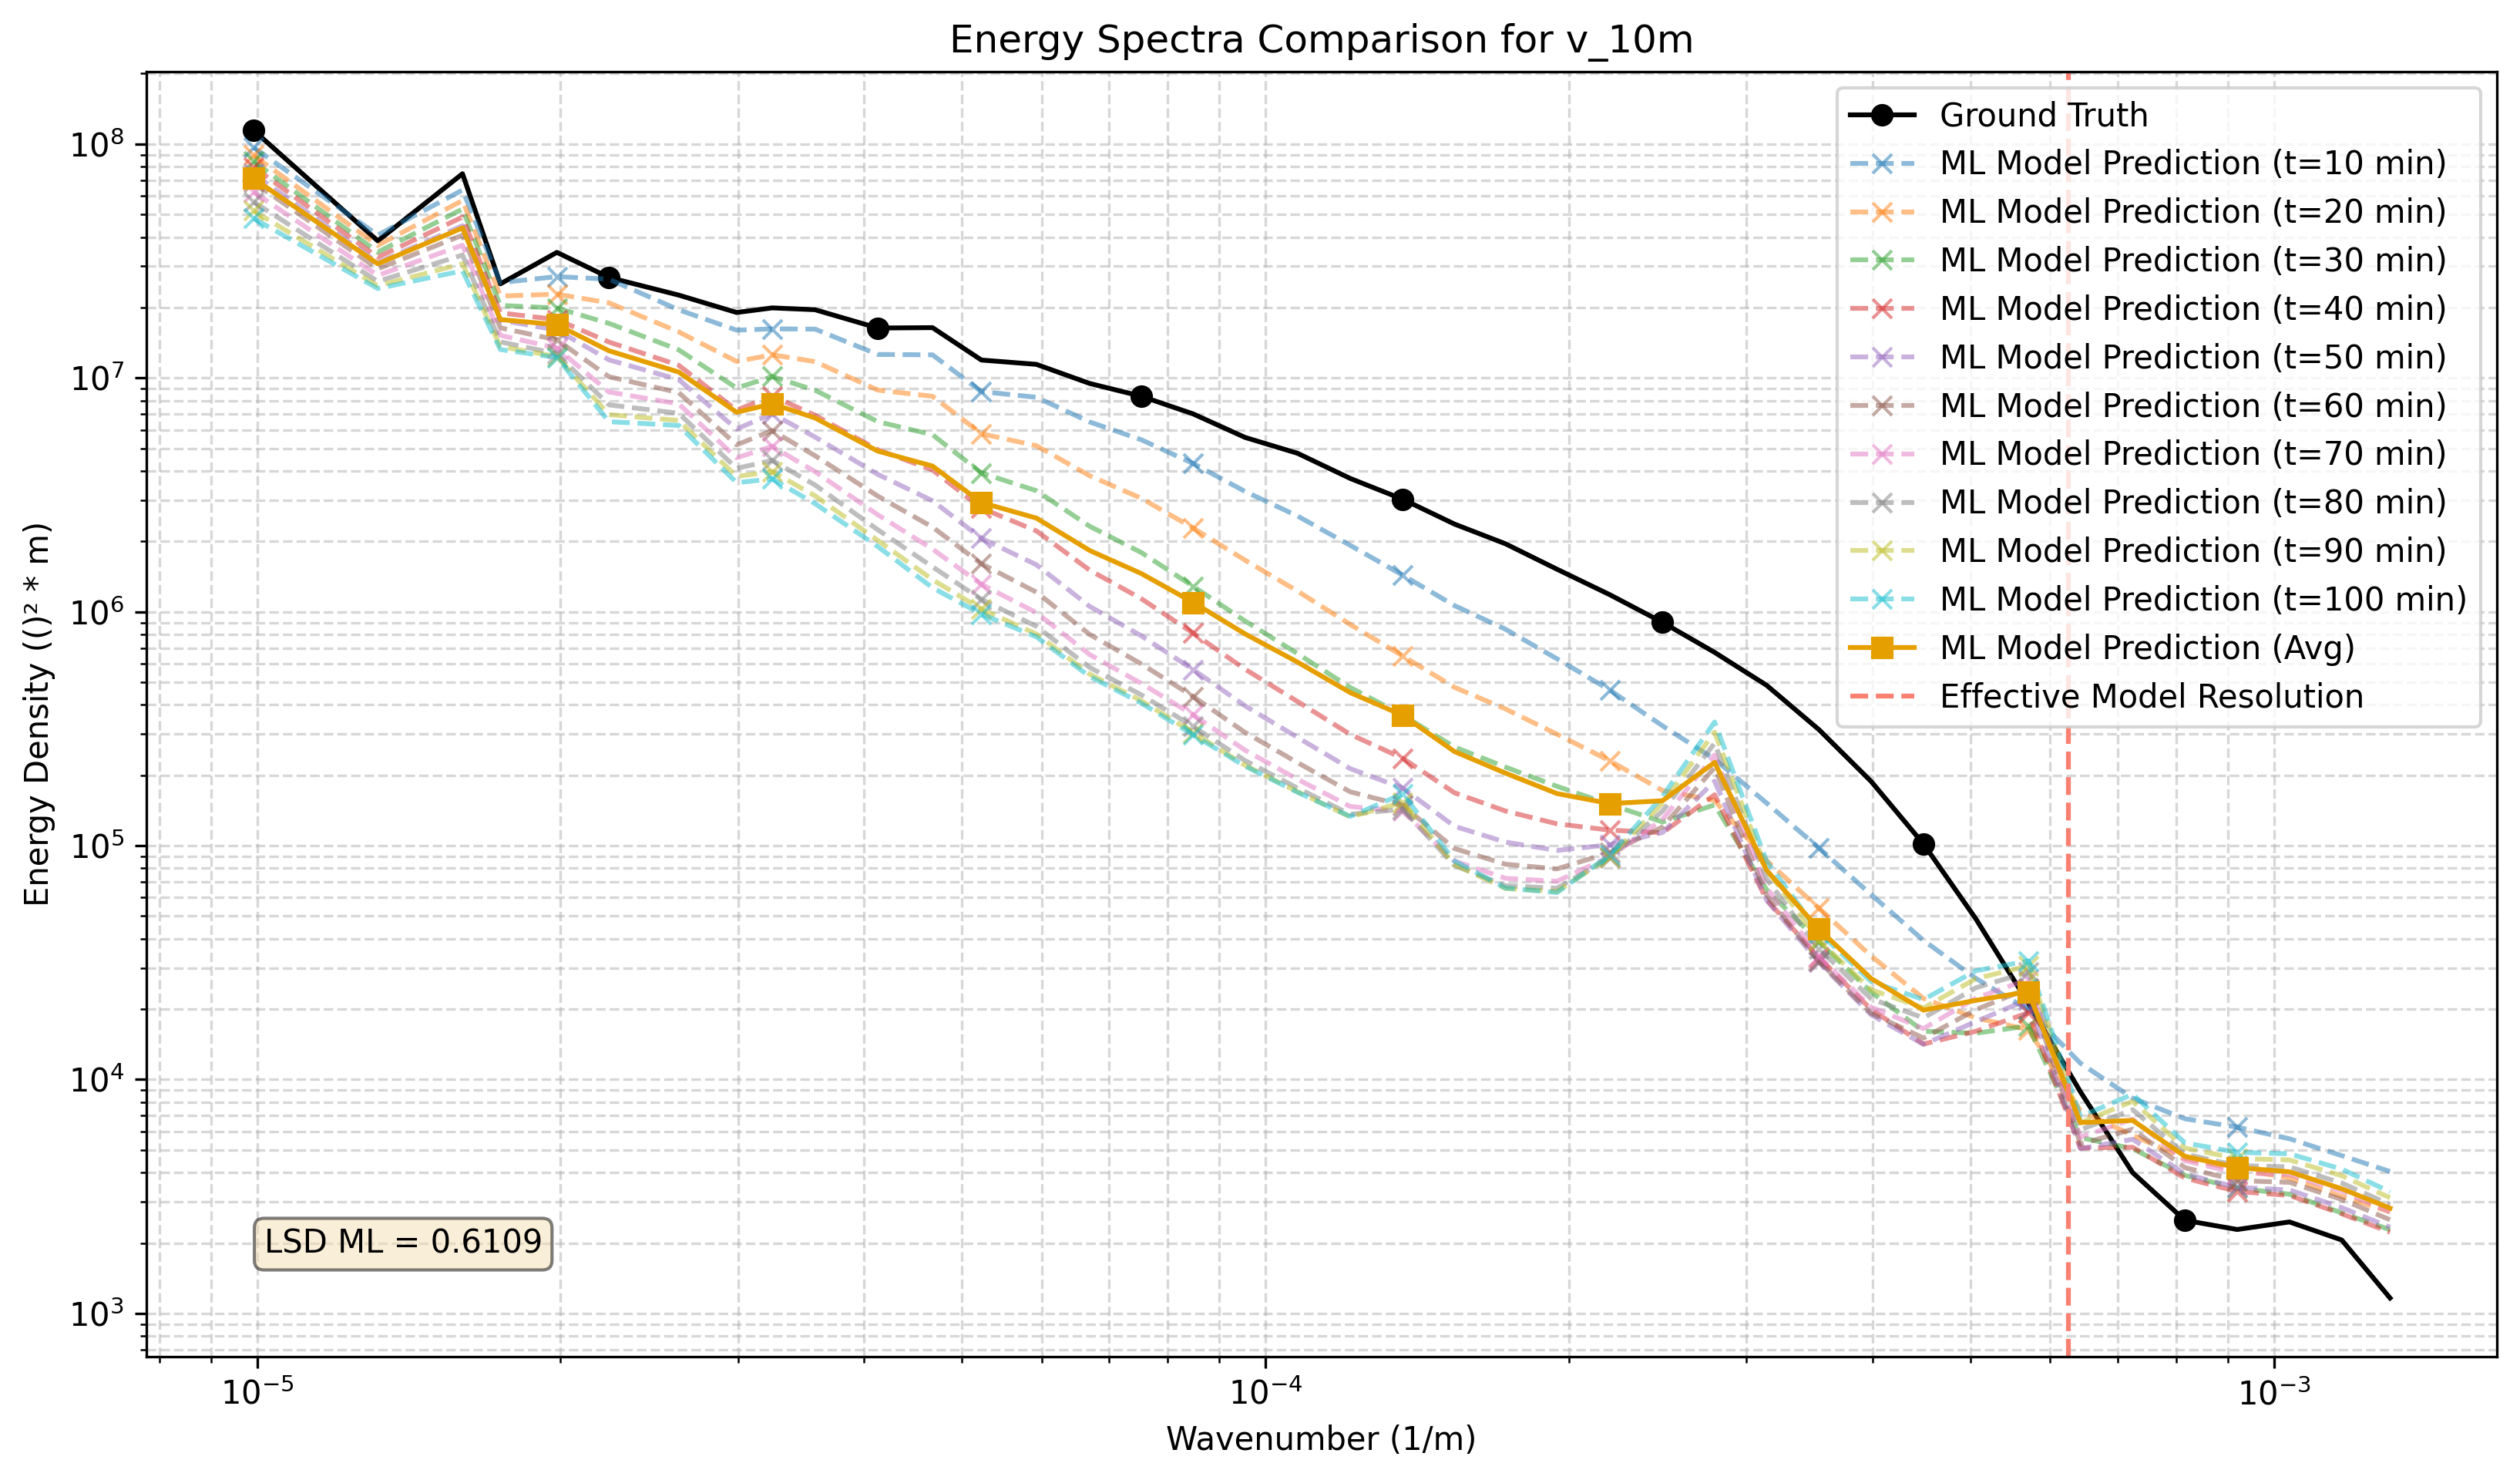

In [28]:
plot_energy_spectra(spectra_cache, "v_10m", show_legend=True, temporal=True)